# Clase 1 · Pre-clase — Introducción a la Ciencia de los Datos

**Qué haces antes de venir a clase (60-90 min):**
1. Lee este notebook completo.
2. Ejecuta cada celda de código para ver los outputs.
3. Responde las **celdas de reflexión** (marcadas 🟡). Sube el notebook completado a Moodle antes de tu clase.

**Al terminar deberías poder:**
- Explicar en qué se distingue "análisis de datos" de "ciencia de datos".
- Nombrar las 6 fases típicas del ciclo de vida de un proyecto de datos (CRISP-DM).
- Describir por qué elegimos Saber 11 como caso de estudio del curso.

## ¿Qué es ciencia de datos?

El **análisis de datos** tradicional (también llamado Business Intelligence o BI) consiste en describir el pasado: construir dashboards, calcular KPIs, responder preguntas como "¿Cuántas unidades vendimos el mes pasado por región?" o "¿Cuál fue la tasa de deserción estudiantil en 2023?". Las herramientas clásicas son Excel, Tableau, Power BI y consultas SQL. El analista transforma datos históricos en visualizaciones e informes que apoyan decisiones humanas.

La **ciencia de datos** va un paso más allá: además de describir el pasado, *predice el futuro* y *automatiza decisiones*. Un modelo de machine learning puede anticipar qué estudiantes tienen mayor riesgo de desertar antes de que ocurra, qué zona de la ciudad concentrará más siniestros viales el próximo viernes por la noche, o qué precio tendrá una fruta en el mercado mayorista la semana entrante. La ciencia de datos combina estadística, programación y comprensión del dominio para extraer conocimiento accionable de datos masivos y complejos.

## Ciclo de vida de un proyecto de datos: CRISP-DM

CRISP-DM (*Cross-Industry Standard Process for Data Mining*) es el marco de trabajo más usado en proyectos de ciencia de datos. Define **6 fases iterativas**:

```
Business Understanding
       ↓
Data Understanding
       ↓
Data Preparation
       ↓
    Modeling
       ↓
   Evaluation
       ↓
  Deployment
       ↑ (retroalimentación a cualquier fase anterior)
```

**1. Business Understanding** — Definir el problema de negocio o académico que se quiere resolver. ¿Cuál es la pregunta? ¿Qué decisión tomará el resultado? ¿Cómo se mide el éxito? Esta fase es crítica: un modelo técnicamente impecable que responde la pregunta equivocada no sirve.

**2. Data Understanding** — Explorar los datos disponibles: qué variables existen, cuántos registros, qué calidad tienen, si hay valores faltantes o atípicos. El objetivo es formarse una imagen honesta de los datos antes de invertir en prepararlos.

**3. Data Preparation** — Limpiar, transformar e integrar los datos para que sean aptos para el modelado. Incluye imputación de nulos, codificación de variables categóricas, normalización, ingeniería de características y partición en conjuntos de entrenamiento y prueba. Suele consumir el 60–80% del tiempo del proyecto.

**4. Modeling** — Seleccionar y entrenar algoritmos (regresión, árboles de decisión, redes neuronales, etc.) sobre los datos preparados. Se ajustan hiperparámetros y se comparan varias alternativas.

**5. Evaluation** — Medir el desempeño del modelo con métricas apropiadas (RMSE, AUC, F1, etc.) y verificar que responda realmente la pregunta del negocio. Aquí se decide si el modelo está listo o si hay que volver a fases anteriores.

**6. Deployment** — Poner el modelo en producción: un API, un dashboard, un informe automatizado, o una integración en un sistema existente. Incluye monitoreo continuo para detectar degradación del modelo con el tiempo.

### 🟡 Reflexión 1

Describe con tus propias palabras la diferencia entre "un analista construye un dashboard de ventas" y "un científico de datos construye un modelo que predice ventas del próximo trimestre". ¿En qué fase del CRISP-DM se enfoca cada uno?

_Escribe tu respuesta acá (2-4 frases):_

_(tu respuesta)_

## El caso del curso: Saber 11

A lo largo del semestre usaremos el dataset **Saber 11** como caso longitudinal de clase. ¿Por qué este dataset?

- **Familiaridad:** todos los estudiantes del curso presentaron la prueba Saber 11. Conocen el contexto desde adentro.
- **Riqueza dimensional:** combina variables de tiempo (año de presentación), geografía (municipio, departamento), tipo de colegio (oficial/privado, zona urbana/rural, jornada), familia (estrato socioeconómico, nivel educativo de los padres) y desempeño individual (puntajes por área).
- **Target predictivo claro:** la variable `PUNT_GLOBAL` (puntaje total) es un objetivo de regresión bien definido. También se puede reformular como clasificación (¿el estudiante supera la media?).
- **Variables socioeconómicas + escolares + geográficas:** permiten explorar relaciones multidimensionales y preguntas de equidad.
- **Dimensión ética:** el dataset pone sobre la mesa preguntas importantes: ¿predecir el rendimiento a partir del estrato perpetúa desigualdades? ¿Cómo usamos estos modelos responsablemente?

> **Nota sobre los datos:** Si la muestra actual es sintética (verificable en `datos/saber11_metadata.json`), tiene **exactamente la misma estructura** que los datos reales del ICFES. Todo lo que aprendan hoy — carga, exploración, limpieza, modelado — se transfiere directamente cuando descarguen los datos oficiales.

In [2]:
import pandas as pd
from pathlib import Path

DATOS = Path("../..") / "datos" / "saber11_muestra_500k.csv"
df = pd.read_csv(DATOS)
print(f"Filas: {len(df):,}  Columnas: {len(df.columns)}")
df.head()

Filas: 500,000  Columnas: 22


,PERIODO,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_DEPTO_RESIDE,ESTU_MCPIO_RESIDE,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,COLE_NATURALEZA,...,COLE_BILINGUE,COLE_DEPTO_UBICACION,COLE_MCPIO_UBICACION,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,PUNT_GLOBAL,DESEMP_INGLES
0,20194,M,20/10/2003,ATLÁNTICO,BARRANQUILLA,2,No,Educación profesional completa,Ninguno,OFICIAL,...,N,ATLÁNTICO,BARRANQUILLA,48,51,26,14,67,194,A2
1,20224,F,10/12/2002,BOLÍVAR,CARTAGENA,1,Si,Educación profesional incompleta,Técnica o tecnológica incompleta,OFICIAL,...,N,BOLÍVAR,CARTAGENA,77,32,64,48,48,199,A-
2,20214,F,18/04/2004,BOGOTÁ D.C.,BOGOTÁ D.C.,3,Si,Ninguno,Educación profesional incompleta,NO OFICIAL,...,N,BOGOTÁ D.C.,BOGOTÁ D.C.,65,43,63,84,48,268,A-
3,20204,F,16/02/2000,NARIÑO,PASTO,4,Si,Primaria incompleta,Postgrado,OFICIAL,...,N,NARIÑO,PASTO,61,45,52,62,49,365,A1
4,20204,F,18/02/2002,BOLÍVAR,CARTAGENA,5,NaN,Técnica o tecnológica incompleta,Educación profesional incompleta,OFICIAL,...,N,BOLÍVAR,CARTAGENA,68,87,52,16,57,355,A1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   PERIODO                   500000 non-null  int64 
 1   ESTU_GENERO               500000 non-null  object
 2   ESTU_FECHANACIMIENTO      500000 non-null  object
 3   ESTU_DEPTO_RESIDE         500000 non-null  object
 4   ESTU_MCPIO_RESIDE         500000 non-null  object
 5   FAMI_ESTRATOVIVIENDA      500000 non-null  int64 
 6   FAMI_TIENEINTERNET        465167 non-null  object
 7   FAMI_EDUCACIONMADRE       465338 non-null  object
 8   FAMI_EDUCACIONPADRE       464928 non-null  object
 9   COLE_NATURALEZA           500000 non-null  object
 10  COLE_JORNADA              500000 non-null  object
 11  COLE_CALENDARIO           500000 non-null  object
 12  COLE_BILINGUE             500000 non-null  object
 13  COLE_DEPTO_UBICACION      500000 non-null  object
 14  COLE

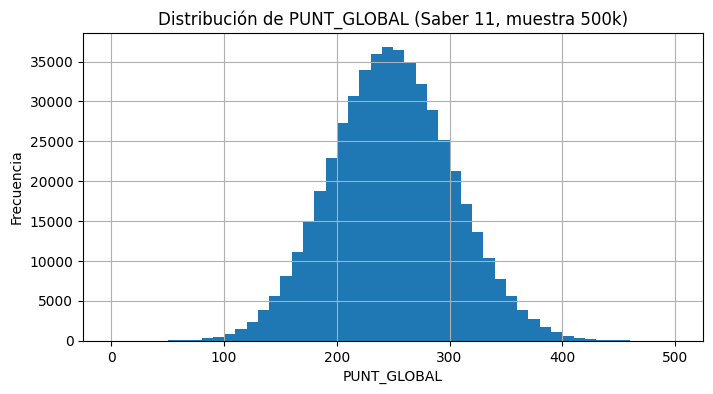

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
df["PUNT_GLOBAL"].hist(bins=50)
plt.title("Distribución de PUNT_GLOBAL (Saber 11, muestra 500k)")
plt.xlabel("PUNT_GLOBAL")
plt.ylabel("Frecuencia")
plt.show()

In [5]:
df.groupby("FAMI_ESTRATOVIVIENDA")["PUNT_GLOBAL"].agg(["mean", "median", "count"]).sort_index()

,mean,median,count
FAMI_ESTRATOVIVIENDA,,,
1,220.211650,220.0,109615
2,235.092119,235.0,150393
3,255.088545,255.0,119962
4,274.771861,275.0,64877
5,290.067732,290.0,35109
6,310.194173,310.0,20044


### 🟡 Reflexión 2

Mira la tabla de puntajes por estrato. ¿Qué patrón observas? ¿Por qué crees que aparece? ¿Este patrón por sí solo demuestra causalidad?

_Tu respuesta acá:_

_(tu respuesta)_

## Doble hilo del curso: clase vs. proyecto grupal

El curso funciona con **dos hilos paralelos**:

1. **Hilo de clase** — En cada sesión todos trabajamos con el dataset Saber 11. Los ejercicios, notebooks de clase y exámenes parciales usarán este dataset. Así podemos comparar resultados, discutir en grupo y construir sobre el mismo contexto.

2. **Hilo de proyecto grupal** — Cada grupo elige un dataset diferente del [catálogo de datasets](../../proyectos/catalogo_datasets.md) en la Clase 1 y lo mantiene durante los **tres proyectos** (P1, P2/3 y P4) del semestre.

**Objetivo pedagógico:** al trabajar un dataset distinto al de clase, deben *transferir* lo aprendido a un dominio nuevo — datos de salud, transporte, mercado laboral, etc. Esta transferencia es la evidencia más sólida de que aprendieron realmente, no solo que memorizaron un procedimiento.

## Catálogo de datasets para el proyecto grupal

Los 8 datasets disponibles este semestre (ver catálogo completo en [`../../proyectos/catalogo_datasets.md`](../../proyectos/catalogo_datasets.md)):

| # | Dataset | Target sugerido |
|---|---------|-----------------|
| 1 | **Siniestros viales — Cali** (Alcaldía de Cali, ~90 k registros) | Clasificar gravedad del siniestro |
| 2 | **Dengue — SIVIGILA** (INS Colombia, ~500 k casos) | Predecir incidencia semanal por municipio |
| 3 | **Deserción universitaria — SPADIES** (MEN, ~2 M trayectorias) | Predecir riesgo de deserción estudiantil |
| 4 | **GEIH — Gran Encuesta Integrada de Hogares** (DANE, ~250 k/trimestre) | Predecir informalidad laboral |
| 5 | **Precios SIPSA** (DANE, ~1 M observaciones semanales) | Predecir precio semanal por producto agrícola |
| 6 | **Calidad del aire — IDEAM/SISAIRE** (~5 M mediciones horarias) | Predecir superación de umbral de contaminante |
| 7 | **Delitos SIEDCO — Policía Nacional** (~1.5 M anuales) | Clasificar tipo de delito por contexto |
| 8 | **Matrícula escolar — MEN** (~10 M registros por año) | Predecir cobertura educativa por municipio |

En la Clase 1 cada grupo presenta sus **3 opciones en orden de preferencia**. El profesor asigna la opción #1 salvo conflicto.

### 🟡 Reflexión 3

Lee el catálogo completo (`../../proyectos/catalogo_datasets.md`). Elige 3 datasets en orden de preferencia y explica en 2-3 frases **por qué** te llaman la atención. Traer estas 3 opciones a la Clase 1.

1. Primera opción: ...
2. Segunda opción: ...
3. Tercera opción: ...

_(tu respuesta)_

### 🟡 Reflexión 4

Piensa en tu experiencia con Saber 11. ¿Recuerdas alguna variable de contexto (estrato, colegio, jornada, etc.) que crees que influyó en tu resultado? ¿Cómo la usarías si tuvieras que predecir el PUNT_GLOBAL de un estudiante hoy?

_Tu respuesta acá:_

_(tu respuesta)_

## Herramientas del curso

Estas son las tecnologías que usaremos durante el semestre. Si aún no las tienes instaladas, hazlo antes de la primera clase:

| Herramienta | Versión mínima | Para qué la usamos |
|-------------|---------------|--------------------|
| [Python](https://www.python.org/) | 3.11+ | Lenguaje principal |
| [Jupyter](https://jupyter.org/) (Lab o Notebook) | 4.x | Entorno interactivo de notebooks |
| [pandas](https://pandas.pydata.org/) | 2.x | Manipulación de datos tabulares |
| [matplotlib](https://matplotlib.org/) | 3.x | Visualización básica |
| [seaborn](https://seaborn.pydata.org/) | 0.13+ | Visualización estadística |
| [plotly](https://plotly.com/python/) | 5.x | Visualización interactiva |
| [scikit-learn](https://scikit-learn.org/) | 1.4+ | Modelos de machine learning |
| [PostgreSQL](https://www.postgresql.org/) | 15+ | Bases de datos relacionales |
| [Moodle](https://moodle.univalle.edu.co/) | — | Entrega de tareas y comunicación del curso |

**Instalación rápida** (en un entorno virtual o conda):
```bash
pip install jupyter pandas matplotlib seaborn plotly scikit-learn pyarrow
```

### 🟡 Reflexión 5

Antes de la clase, marca en esta lista qué tan cómodo te sientes con cada tema. Escala: 1 (no lo conozco) — 5 (muy cómodo).

- Python básico: __
- Pandas: __
- SQL y bases relacionales: __
- Visualización con matplotlib/seaborn: __
- Aprendizaje de máquina (regresión, clasificación): __
- Redes neuronales: __

_Esto no afecta tu nota. Sirve para calibrar el ritmo del curso._

## Cierre: ¿cómo se evalúa el curso?

El curso tiene **5 componentes** de evaluación, alineados con los 4 resultados de aprendizaje (RA):

| Componente | RA asociado | Peso |
|------------|------------|------|
| Proyecto 1 | RA1 | 30% |
| Proyectos 2 y 3 | RA2 + RA3 | 30% |
| Examen Parcial 1 | RA3 | 15% |
| Examen Parcial 2 | RA4 | 15% |
| Proyecto 4 | RA4 | 10% |
| **Total** | | **100%** |

Todos los proyectos son grupales (grupos de 3). Los exámenes son individuales. Los detalles de cada proyecto están en los archivos `proyecto*_ra*.md` dentro de la carpeta `proyectos/`.

## ¿Qué llevar a la primera clase?

Antes de llegar a clase el miércoles 26-ago (o jueves 27-ago):

- [ ] Este notebook `01_preclase.ipynb` completado con tus 5 reflexiones y **subido a Moodle**.
- [ ] Tus **3 opciones de dataset** del catálogo, con las razones de tu preferencia (Reflexión 3).
- [ ] Idealmente, ya conformado tu **grupo de 3 personas**. Si aún no tienes grupo, se forma durante la clase.

¡Nos vemos en la primera clase!